In [ ]:
# ran 3 full flightlines through apply_oe w unprocessed rccs - what do the outputs look like?

In [1]:
import isofit
from isofit.core.fileio import IO
from isofit.core.forward import ForwardModel
from isofit.inversion.inverse import Inversion
from isofit.inversion.inverse_simple import invert_algebraic, invert_simple, invert_analytical
from isofit.configs import configs
from isofit.core.geometry import Geometry
from isofit.utils.apply_oe import apply_oe 

from collections import OrderedDict

import os
from spectral.io import envi
import numpy as np
import ray
import logging
import json
from glob import glob
import matplotlib.pyplot as plt

from utilities import viz_rfl_subset

from isoplots import plots
import xarray as xr

%matplotlib widget

# Enable the ISOFIT logger
logging.getLogger().setLevel(logging.INFO)

In [4]:
data = '/store/carroll/col/data/2018/'
home = os.path.join(data, 'test_flightlines/')
raw = os.path.join(data, 'raw/rmbl/')
out_figs = '/store/carroll/col/figs/'

version = '20250909'

flights = ['NIS01_20180612_155442', 'NIS01_20180620_162340', 'NIS01_20180619_162542']

fp_rcc = os.path.join(data, 'test_roi/rcc_white_tarp_mean_20250807.txt')
fp_rcc_v1 = os.path.join(data, 'test_roi/rcc_white_tarp_mean_20250814_v1.txt')
fp_rcc_v2 = os.path.join(data, 'test_roi/rcc_white_tarp_mean_20250814_v2.txt')
fp_rcc_v3 = os.path.join(data, 'test_rccs', 'rcc_frankenstein_20250908.txt')

fp = glob(os.path.join(home, '*', 'output', '*_rfl.hdr'))[0]
wl = np.array([float(x) for x in envi.read_envi_header(fp)['wavelength']])
def closest_wl(mv):
    return np.argmin(np.abs(wl-mv))
wl_nan = wl.copy()
wl_nan[closest_wl(1360):closest_wl(1410)] = np.nan
wl_nan[closest_wl(1800):closest_wl(1970)] = np.nan

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1442.9246..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-372.36172..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-345.82504..1.0].


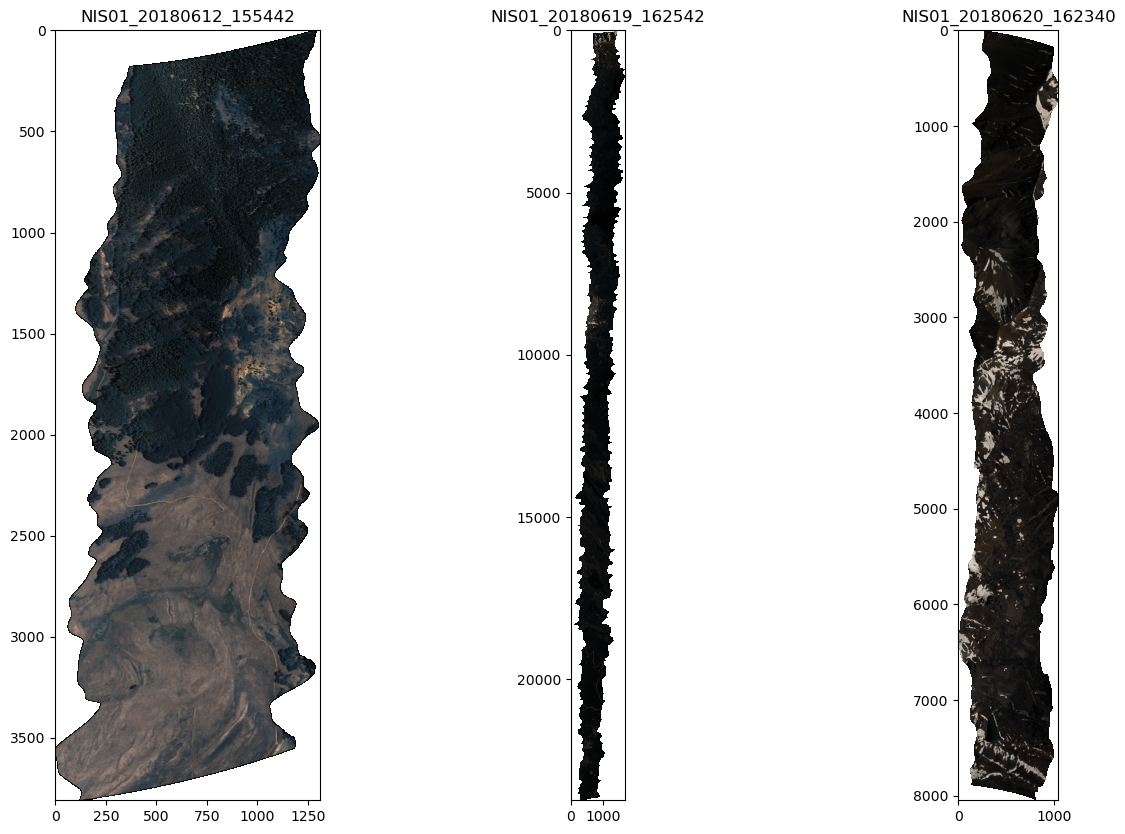

In [3]:
# rfl rgb for all flightlines

fig, axs = plt.subplots(ncols=3, figsize=(15,10))

for i in range(len(flights)):
    flight = flights[i]
    working_dir = glob(os.path.join(home+f'{flight}*'))[0]
    fp = glob(os.path.join(working_dir, 'output', f'{flight}_rfl.hdr'))[0]
    rgb = envi.open(fp).open_memmap()[:,:,np.array([60,40,30])].copy()
    axs[i].imshow(rgb / np.nanmax(rgb, axis=(0, 1)))
    axs[i].set_title(flight)

plt.show()

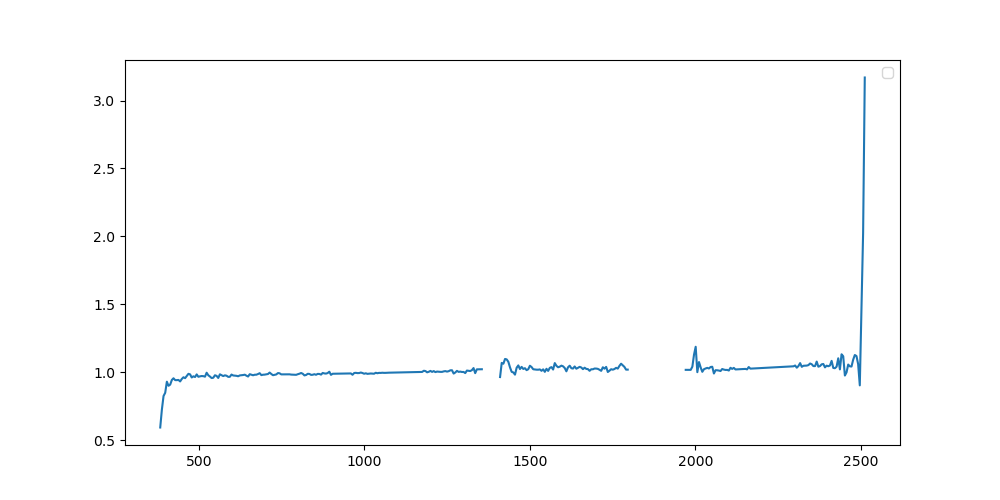

In [3]:
# load, plot rccs 

# rcc_raw = np.loadtxt(fp_rcc) # these are what were used int retrievals below
# rcc_v1 = np.loadtxt(fp_rcc_v1)
# rcc_v2 = np.loadtxt(fp_rcc_v2)
rcc = np.loadtxt(fp_rcc_v3)

fig = plt.figure(figsize=(10,5))

# wl_ = wl
wl_ = wl_nan

# plt.plot(wl_, rcc_raw, label='rcc raw')
# plt.plot(wl_, rcc_v2, label='rcc v2')
# plt.plot(wl_, rcc_v1, label='rcc v1')
plt.plot(wl_, rcc)

plt.legend()
plt.show()

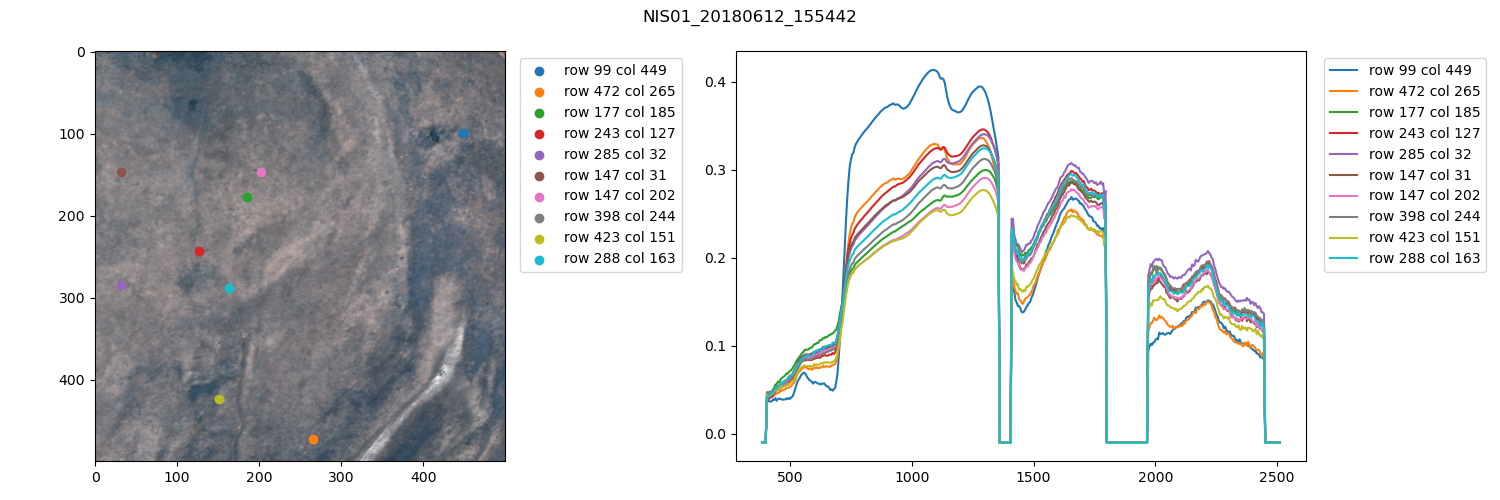

In [13]:
# plot some spectra

flight = flights[0]
working_dir = glob(os.path.join(home, f'{flight}_{version}'))[0]

size = 500
# row1 = 2000; col1 = 600
row1 = 3000; col1 = 500

viz_rfl_subset(flight=flight, working_dir=working_dir, row1=row1, col1=col1, size=size, n_sample=10, wl=wl)

plt.savefig(os.path.join(out_figs, f'rfl_{flight}_{version}_row{row1}_col{col1}.png'), dpi=300)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0023965905..1.0].


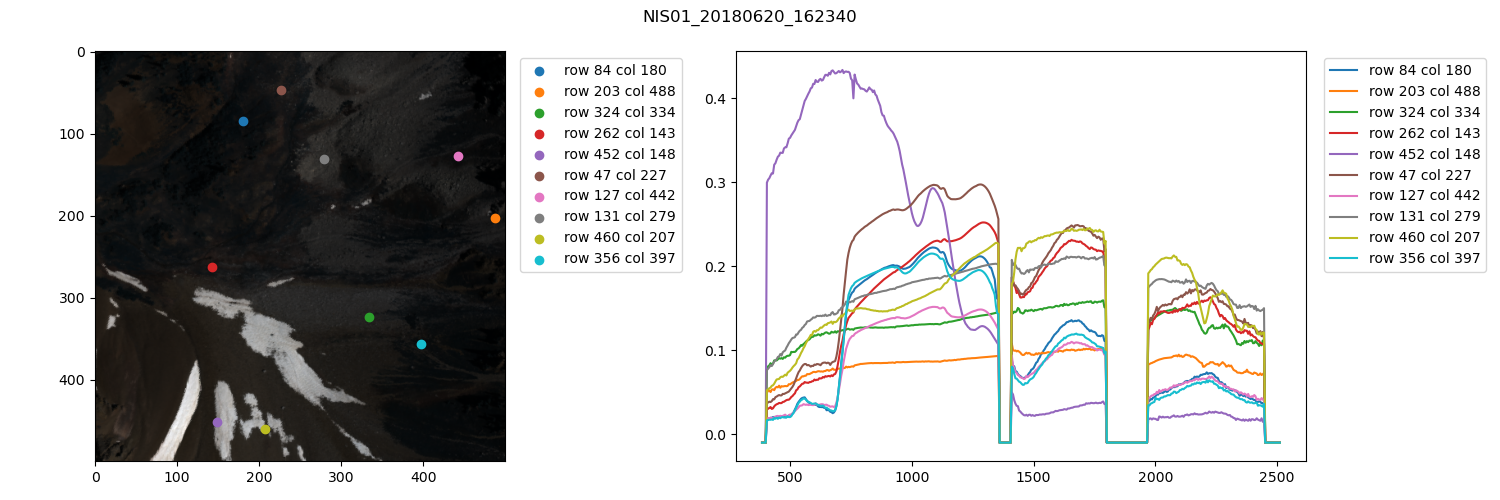

In [18]:
# plot some spectra

flight = flights[1]
working_dir = glob(os.path.join(home, f'{flight}_{version}'))[0]

size = 500
row1 = 2000; col1 = 200
# row1 = 13200; col1 = 650
# row1 = 8600; col1 = 600

viz_rfl_subset(flight=flight, working_dir=working_dir, row1=row1, col1=col1, size=size, n_sample=10, wl=wl)

plt.savefig(os.path.join(out_figs, f'rfl_{flight}_{version}_row{row1}_col{col1}.png'), dpi=300)